# CycleGAN — DIP Joint Disease Simulation (Stage 1 Baseline)

**Author:** Jai Sharma  
**Location:** `CV-Project/members/jai/`  
**Date:** April 2026  

---

## What this notebook does

Trains a CycleGAN to translate DIP joint X-rays between two domains:
- **Domain A** = KL 0-1 (healthy/doubtful joints)
- **Domain B** = KL 2+ (osteoarthritic joints)

The model learns to:
1. Convert healthy joints → diseased-looking joints (Generator A→B)
2. Convert diseased joints → healthy-looking joints (Generator B→A)

This is our **baseline model** — results will be compared against the Latent Diffusion Model.

---

## Input data
- `data/splits/manifest_dip_only.csv` — training split only
- `data/raw/Finger_Joints.zip` — extracted to local `/content/` each session
- Image size: 180×180 grayscale PNG
- Normalization: mean=0.2339, std=0.2349

## Output files (Zulal's eval format)
All outputs go to `models/cyclegan_outputs/`:

| File/Folder | Description |
|---|---|
| `images/` | All generated PNGs |
| `images_by_kl/kl2plus/` | Synthetic diseased images (for FID) |
| `images_by_kl/kl0/` | Synthetic healthy images (for FID) |
| `synthetic_manifest.csv` | filename, KL, joint_type, source |
| `training_log.json` | Hyperparameters + loss history |
| `training_curves.png` | Loss plots |
| `visual_qc.png` | Real vs synthetic comparison |

## Key decisions
- Domain A = KL 0 + KL 1 (per professor guidance)
- No RandomVerticalFlip (X-rays are always upright)
- Binary labels: "KL 2+" and "KL 0-1" (not individual grades)
- Seed 42 for reproducibility (matching Maria's setup)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/CV-Project'
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'models', 'cyclegan_checkpoints')

print("Saved checkpoints:")
for f in sorted(os.listdir(CHECKPOINT_DIR)):
    size = os.path.getsize(os.path.join(CHECKPOINT_DIR, f)) / 1e6
    print(f"  {f} — {size:.1f} MB")

Mounted at /content/drive
Saved checkpoints:
  cyclegan_epoch_025.pth — 254.2 MB
  cyclegan_epoch_050.pth — 254.2 MB
  cyclegan_epoch_075.pth — 254.2 MB
  cyclegan_epoch_100.pth — 254.2 MB
  cyclegan_final.pth — 84.7 MB


In [ ]:
# ============================================================================
# CELL 1: SETUP
# ============================================================================

import os
import shutil
import zipfile
import time
import random
import json
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import itertools
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ── CHANGE THIS IF NEEDED ──
PROJECT_ROOT = '/content/drive/MyDrive/CV-Project'

RAW_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw')
SPLITS_DIR = os.path.join(PROJECT_ROOT, 'data', 'splits')

# Output dirs — matching Zulal's expected structure
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'models', 'cyclegan_outputs')
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'models', 'cyclegan_checkpoints')
SAMPLES_DIR = os.path.join(OUTPUT_DIR, 'training_samples')

for d in [OUTPUT_DIR, CHECKPOINT_DIR, SAMPLES_DIR,
          os.path.join(OUTPUT_DIR, 'images'),
          os.path.join(OUTPUT_DIR, 'images_by_kl', 'kl0'),
          os.path.join(OUTPUT_DIR, 'images_by_kl', 'kl2plus')]:
    os.makedirs(d, exist_ok=True)

# Extract images to local disk (ALWAYS force re-extract for fresh session)
LOCAL_IMG_DIR = '/content/finger_joints_images'
if os.path.exists(LOCAL_IMG_DIR):
    shutil.rmtree(LOCAL_IMG_DIR)

zip_path = os.path.join(RAW_DIR, 'Finger_Joints.zip')
print(f'Extracting images to local disk...')
start = time.time()
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(LOCAL_IMG_DIR)
print(f'Done in {time.time()-start:.1f}s')

# Verify extraction
all_pngs = glob.glob(os.path.join(LOCAL_IMG_DIR, '**', '*.png'), recursive=True)
print(f'Extracted {len(all_pngs)} images')
if all_pngs:
    IMG_PARENT = os.path.dirname(all_pngs[0])
    print(f'Images located in: {IMG_PARENT}')
else:
    raise RuntimeError('No images extracted! Check zip file.')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'PyTorch: {torch.__version__}')

Extracting images to local disk...
Done in 21.6s
Extracted 41060 images
Images located in: /content/finger_joints_images/Finger Joints

Device: cuda
GPU: Tesla T4
PyTorch: 2.10.0+cu128


In [ ]:
# ============================================================================
# CELL 2: LOAD MANIFEST & CREATE DOMAIN SPLITS
# ============================================================================
df = pd.read_csv(os.path.join(SPLITS_DIR, 'manifest_dip_only.csv'))
print(f'Total DIP images: {len(df)}')
print(f'Columns: {list(df.columns)}')

# Auto-detect KL column name
if 'KL' in df.columns:
    kl_col = 'KL'
elif 'v00_KL' in df.columns:
    kl_col = 'v00_KL'
else:
    kl_cols = [c for c in df.columns if 'KL' in c.upper()]
    kl_col = kl_cols[0]
print(f'Using KL column: {kl_col}')

# Fix image paths to current local extraction
def fix_path(old_path):
    fname = os.path.basename(old_path)
    new_path = os.path.join(IMG_PARENT, fname)
    return new_path if os.path.exists(new_path) else old_path

df['image_path'] = df['image_path'].apply(fix_path)
valid = df['image_path'].apply(os.path.exists).sum()
print(f'Valid image paths: {valid}/{len(df)}')

if valid == 0:
    raise RuntimeError('No valid image paths! Check extraction folder.')

# Training set only
train = df[df['split'] == 'train'].copy()

# Domain A = KL 0 + KL 1 (healthy) | Domain B = KL 2+ (diseased)
domain_a_df = train[train[kl_col] <= 1].reset_index(drop=True)
domain_b_df = train[train[kl_col] >= 2].reset_index(drop=True)

print(f'\nDomain A (KL 0-1, healthy):   {len(domain_a_df)} images')
print(f'  KL 0: {len(train[train[kl_col]==0])}')
print(f'  KL 1: {len(train[train[kl_col]==1])}')
print(f'Domain B (KL 2+, diseased):   {len(domain_b_df)} images')
print(f'  KL 2: {len(train[train[kl_col]==2])}')
print(f'  KL 3: {len(train[train[kl_col]==3])}')
print(f'  KL 4: {len(train[train[kl_col]==4])}')

Total DIP images: 13176
Columns: ['patient_id', 'timepoint', 'joint_type', 'joint_num', 'joint_id', 'CY', 'v00_ER', 'v00_JSN', 'v00_KL', 'ME', 'v00_OP', 'PW', 'image_path', 'split', 'v06_KL', 'v06_JSN', 'v06_OP', 'v06_ER']
Using KL column: v00_KL
Valid image paths: 13176/13176

Domain A (KL 0-1, healthy):   7167 images
  KL 0: 5947
  KL 1: 1220
Domain B (KL 2+, diseased):   2032 images
  KL 2: 1770
  KL 3: 144
  KL 4: 118


In [ ]:
# ============================================================================
# CELL 3: DATASET & DATALOADER (no vertical flip per Zulal's note)
# ============================================================================
IMG_SIZE = 180

transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.2339], std=[0.2349]),
])

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.2339], std=[0.2349]),
])


class UnpairedDataset(Dataset):
    def __init__(self, paths_a, paths_b, transform=None):
        self.paths_a = paths_a
        self.paths_b = paths_b
        self.transform = transform
        self.len_a = len(paths_a)
        self.len_b = len(paths_b)

    def __len__(self):
        return max(self.len_a, self.len_b)

    def __getitem__(self, idx):
        img_a = Image.open(self.paths_a[idx % self.len_a]).convert('L')
        img_b = Image.open(self.paths_b[random.randint(0, self.len_b - 1)]).convert('L')
        if self.transform:
            img_a = self.transform(img_a)
            img_b = self.transform(img_b)
        return img_a, img_b


dataset = UnpairedDataset(
    domain_a_df['image_path'].tolist(),
    domain_b_df['image_path'].tolist(),
    transform=transform_train
)

dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
print(f'Dataloader: {len(dataloader)} batches of size 8')

a, b = next(iter(dataloader))
print(f'Batch shapes — A: {a.shape}, B: {b.shape}')

Dataloader: 896 batches of size 8
Batch shapes — A: torch.Size([8, 1, 180, 180]), B: torch.Size([8, 1, 180, 180])


In [ ]:
# ============================================================================
# CELL 4: MODEL ARCHITECTURE
# ============================================================================

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class Generator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, n_residual=6, n_features=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_channels, n_features, 7),
            nn.InstanceNorm2d(n_features),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_features, n_features * 2, 3, stride=2, padding=1),
            nn.InstanceNorm2d(n_features * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_features * 2, n_features * 4, 3, stride=2, padding=1),
            nn.InstanceNorm2d(n_features * 4),
            nn.ReLU(inplace=True),
        )
        self.res_blocks = nn.Sequential(*[ResidualBlock(n_features * 4) for _ in range(n_residual)])
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(n_features * 4, n_features * 2, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(n_features * 2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(n_features * 2, n_features, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(n_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(3),
            nn.Conv2d(n_features, out_channels, 7),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.decoder(self.res_blocks(self.encoder(x)))


class Discriminator(nn.Module):
    def __init__(self, in_channels=1, n_features=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, n_features, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(n_features, n_features * 2, 4, stride=2, padding=1),
            nn.InstanceNorm2d(n_features * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(n_features * 2, n_features * 4, 4, stride=2, padding=1),
            nn.InstanceNorm2d(n_features * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(n_features * 4, n_features * 8, 4, stride=1, padding=1),
            nn.InstanceNorm2d(n_features * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(n_features * 8, 1, 4, stride=1, padding=1),
        )

    def forward(self, x):
        return self.model(x)


G_AB = Generator().to(device)
G_BA = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

total_params = sum(p.numel() for m in [G_AB, G_BA, D_A, D_B] for p in m.parameters())
print(f'Total parameters: {total_params:,}')
print(f'  G_AB: {sum(p.numel() for p in G_AB.parameters()):,}')
print(f'  G_BA: {sum(p.numel() for p in G_BA.parameters()):,}')
print(f'  D_A:  {sum(p.numel() for p in D_A.parameters()):,}')
print(f'  D_B:  {sum(p.numel() for p in D_B.parameters()):,}')

Total parameters: 21,175,684
  G_AB: 7,825,153
  G_BA: 7,825,153
  D_A:  2,762,689
  D_B:  2,762,689


In [ ]:
# ============================================================================
# CELL 5: TRAINING SETUP
# ============================================================================
NUM_EPOCHS = 100
LR = 0.0002
BETA1 = 0.5
LAMBDA_CYCLE = 10.0
LAMBDA_IDENTITY = 5.0

opt_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=LR, betas=(BETA1, 0.999))
opt_D_A = torch.optim.Adam(D_A.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_D_B = torch.optim.Adam(D_B.parameters(), lr=LR, betas=(BETA1, 0.999))

def lr_lambda(epoch):
    decay_start = NUM_EPOCHS // 2
    if epoch < decay_start:
        return 1.0
    return 1.0 - (epoch - decay_start) / (NUM_EPOCHS - decay_start + 1)

sched_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_lambda)
sched_D_A = torch.optim.lr_scheduler.LambdaLR(opt_D_A, lr_lambda)
sched_D_B = torch.optim.lr_scheduler.LambdaLR(opt_D_B, lr_lambda)

criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()


class ReplayBuffer:
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, data):
        result = []
        for img in data:
            img = img.unsqueeze(0)
            if len(self.data) < self.max_size:
                self.data.append(img)
                result.append(img)
            elif random.random() > 0.5:
                idx = random.randint(0, self.max_size - 1)
                result.append(self.data[idx].clone())
                self.data[idx] = img
            else:
                result.append(img)
        return torch.cat(result, 0)


buffer_A = ReplayBuffer()
buffer_B = ReplayBuffer()

print(f'Training config:')
print(f'  Epochs: {NUM_EPOCHS}')
print(f'  LR: {LR} (linear decay from epoch {NUM_EPOCHS//2})')
print(f'  Lambda cycle: {LAMBDA_CYCLE}, Lambda identity: {LAMBDA_IDENTITY}')
print(f'  Batch size: 8')
print(f'  Domain A: {len(domain_a_df)} images (KL 0-1)')
print(f'  Domain B: {len(domain_b_df)} images (KL 2+)')

Training config:
  Epochs: 100
  LR: 0.0002 (linear decay from epoch 50)
  Lambda cycle: 10.0, Lambda identity: 5.0
  Batch size: 8
  Domain A: 7167 images (KL 0-1)
  Domain B: 2032 images (KL 2+)


In [ ]:
# ============================================================================
# CELL 6: HELPER — DENORMALIZE & SAVE SAMPLES
# ============================================================================
def denormalize(tensor):
    return tensor * 0.2349 + 0.2339

def save_samples(epoch, real_a, real_b, G_AB, G_BA, save_dir):
    G_AB.eval()
    G_BA.eval()
    n = min(4, real_a.size(0), real_b.size(0))
    with torch.no_grad():
        fake_b = G_AB(real_a[:n])
        recon_a = G_BA(fake_b)
        fake_a = G_BA(real_b[:n])
        recon_b = G_AB(fake_a)
    fig, axes = plt.subplots(n, 6, figsize=(18, 3*n))
    titles = ['Real KL0-1', 'Fake KL2+', 'Recon KL0-1', 'Real KL2+', 'Fake KL0-1', 'Recon KL2+']
    for i in range(n):
        imgs = [
            denormalize(real_a[i]).cpu().squeeze(),
            denormalize(fake_b[i]).cpu().squeeze(),
            denormalize(recon_a[i]).cpu().squeeze(),
            denormalize(real_b[i]).cpu().squeeze(),
            denormalize(fake_a[i]).cpu().squeeze(),
            denormalize(recon_b[i]).cpu().squeeze(),
        ]
        for j, img in enumerate(imgs):
            axes[i][j].imshow(img.clamp(0, 1), cmap='gray')
            if i == 0:
                axes[i][j].set_title(titles[j], fontsize=11)
            axes[i][j].axis('off')
    plt.suptitle(f'Epoch {epoch}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'epoch_{epoch:03d}.png'), dpi=100, bbox_inches='tight')
    plt.close()
    G_AB.train()
    G_BA.train()

print('Helper functions ready.')

Helper functions ready.


In [ ]:
# ============================================================================
# CELL 7: TRAINING LOOP
# ============================================================================
history = {'g_loss': [], 'd_loss': [], 'cycle_loss': [], 'epoch_time': []}

print(f'Starting training — {NUM_EPOCHS} epochs, {len(dataloader)} batches/epoch')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_g_loss = 0
    epoch_d_loss = 0
    epoch_cycle_loss = 0
    epoch_start = time.time()

    for i, (real_a, real_b) in enumerate(tqdm(dataloader, desc=f'Epoch {epoch}/{NUM_EPOCHS}', leave=False)):
        real_a = real_a.to(device)
        real_b = real_b.to(device)
        valid = torch.ones_like(D_A(real_a), device=device)
        fake_label = torch.zeros_like(D_A(real_a), device=device)

        # Train Generators
        opt_G.zero_grad()
        loss_id_a = criterion_identity(G_BA(real_a), real_a) * LAMBDA_IDENTITY
        loss_id_b = criterion_identity(G_AB(real_b), real_b) * LAMBDA_IDENTITY
        fake_b = G_AB(real_a)
        loss_gan_ab = criterion_GAN(D_B(fake_b), valid)
        fake_a = G_BA(real_b)
        loss_gan_ba = criterion_GAN(D_A(fake_a), valid)
        recon_a = G_BA(fake_b)
        loss_cycle_a = criterion_cycle(recon_a, real_a) * LAMBDA_CYCLE
        recon_b = G_AB(fake_a)
        loss_cycle_b = criterion_cycle(recon_b, real_b) * LAMBDA_CYCLE
        loss_G = loss_gan_ab + loss_gan_ba + loss_cycle_a + loss_cycle_b + loss_id_a + loss_id_b
        loss_G.backward()
        opt_G.step()

        # Train Discriminator A
        opt_D_A.zero_grad()
        fake_a_buf = buffer_A.push_and_pop(fake_a.detach())
        loss_d_a = (criterion_GAN(D_A(real_a), valid) + criterion_GAN(D_A(fake_a_buf), fake_label)) * 0.5
        loss_d_a.backward()
        opt_D_A.step()

        # Train Discriminator B
        opt_D_B.zero_grad()
        fake_b_buf = buffer_B.push_and_pop(fake_b.detach())
        loss_d_b = (criterion_GAN(D_B(real_b), valid) + criterion_GAN(D_B(fake_b_buf), fake_label)) * 0.5
        loss_d_b.backward()
        opt_D_B.step()

        epoch_g_loss += loss_G.item()
        epoch_d_loss += (loss_d_a.item() + loss_d_b.item())
        epoch_cycle_loss += (loss_cycle_a.item() + loss_cycle_b.item())

    n_batches = len(dataloader)
    epoch_time = time.time() - epoch_start
    avg_g = epoch_g_loss / n_batches
    avg_d = epoch_d_loss / n_batches
    avg_c = epoch_cycle_loss / n_batches
    history['g_loss'].append(avg_g)
    history['d_loss'].append(avg_d)
    history['cycle_loss'].append(avg_c)
    history['epoch_time'].append(epoch_time)
    sched_G.step()
    sched_D_A.step()
    sched_D_B.step()

    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | G: {avg_g:.4f} | D: {avg_d:.4f} | '
          f'Cycle: {avg_c:.4f} | Time: {epoch_time:.1f}s | LR: {sched_G.get_last_lr()[0]:.6f}')

    if epoch % 10 == 0 or epoch == 1:
        save_samples(epoch, real_a, real_b, G_AB, G_BA, SAMPLES_DIR)
        print(f'  → Saved training samples')

    if epoch % 25 == 0:
        ckpt = {'epoch': epoch, 'G_AB': G_AB.state_dict(), 'G_BA': G_BA.state_dict(),
                'D_A': D_A.state_dict(), 'D_B': D_B.state_dict(),
                'opt_G': opt_G.state_dict(), 'opt_D_A': opt_D_A.state_dict(),
                'opt_D_B': opt_D_B.state_dict(), 'history': history}
        torch.save(ckpt, os.path.join(CHECKPOINT_DIR, f'cyclegan_epoch_{epoch:03d}.pth'))
        print(f'  → Saved checkpoint')

# Save final
torch.save({'epoch': NUM_EPOCHS, 'G_AB': G_AB.state_dict(), 'G_BA': G_BA.state_dict(),
            'D_A': D_A.state_dict(), 'D_B': D_B.state_dict(), 'history': history},
           os.path.join(CHECKPOINT_DIR, 'cyclegan_final.pth'))

with open(os.path.join(OUTPUT_DIR, 'training_log.json'), 'w') as f:
    json.dump({'epochs': NUM_EPOCHS, 'lr': LR, 'lambda_cycle': LAMBDA_CYCLE,
               'lambda_identity': LAMBDA_IDENTITY, 'batch_size': 8, 'img_size': IMG_SIZE,
               'domain_a': 'KL 0-1', 'domain_b': 'KL 2+',
               'domain_a_size': len(domain_a_df), 'domain_b_size': len(domain_b_df),
               'seed': 42, 'history': history}, f, indent=2)

print(f'\n{"="*60}')
print(f'Training complete! Total time: {sum(history["epoch_time"])/60:.1f} minutes')

Starting training — 100 epochs, 896 batches/epoch


Epoch   1/100 | G: 10.4553 | D: 0.3030 | Cycle: 6.2000 | Time: 138.9s | LR: 0.000200
  → Saved training samples


Epoch   2/100 | G: 10.0556 | D: 0.1933 | Cycle: 5.6772 | Time: 137.4s | LR: 0.000200


Epoch   3/100 | G: 10.0244 | D: 0.1279 | Cycle: 5.5540 | Time: 137.4s | LR: 0.000200


Epoch   4/100 | G: 9.8193 | D: 0.1565 | Cycle: 5.4304 | Time: 137.4s | LR: 0.000200


...

Epoch  96/100 | G: 8.1878 | D: 0.0689 | Cycle: 4.2321 | Time: 137.4s | LR: 0.000020


Epoch  97/100 | G: 8.0769 | D: 0.0709 | Cycle: 4.1612 | Time: 137.4s | LR: 0.000016


Epoch  98/100 | G: 8.1404 | D: 0.0694 | Cycle: 4.2022 | Time: 137.5s | LR: 0.000012


Epoch  99/100 | G: 8.1147 | D: 0.0701 | Cycle: 4.1848 | Time: 137.7s | LR: 0.000008


Epoch 100/100:  65%|██████▍   | 579/896 [01:28<00:48,  6.51it/s]

In [2]:
# RELOAD — skip training, load saved model
import os, shutil, json, time, random, glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

PROJECT_ROOT = '/content/drive/MyDrive/CV-Project'
RAW_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw')
SPLITS_DIR = os.path.join(PROJECT_ROOT, 'data', 'splits')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'models', 'cyclegan_outputs')
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'models', 'cyclegan_checkpoints')
SAMPLES_DIR = os.path.join(OUTPUT_DIR, 'training_samples')
IMG_SIZE = 180

for d in [OUTPUT_DIR, os.path.join(OUTPUT_DIR, 'images'),
          os.path.join(OUTPUT_DIR, 'images_by_kl', 'kl0'),
          os.path.join(OUTPUT_DIR, 'images_by_kl', 'kl2plus')]:
    os.makedirs(d, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device assigned: {device}")
print(f"Device: {device}")

# Extract images
LOCAL_IMG_DIR = '/content/finger_joints_images'
if os.path.exists(LOCAL_IMG_DIR):
    shutil.rmtree(LOCAL_IMG_DIR)
import zipfile
print("Extracting images...")
start = time.time()
with zipfile.ZipFile(os.path.join(RAW_DIR, 'Finger_Joints.zip'), 'r') as z:
    z.extractall(LOCAL_IMG_DIR)
print(f"Done in {time.time()-start:.1f}s")

all_pngs = glob.glob(os.path.join(LOCAL_IMG_DIR, '**', '*.png'), recursive=True)
IMG_PARENT = os.path.dirname(all_pngs[0])
print(f"Images: {len(all_pngs)} in {IMG_PARENT}")

# Load manifest
df = pd.read_csv(os.path.join(SPLITS_DIR, 'manifest_dip_only.csv'))
kl_col = 'KL' if 'KL' in df.columns else 'v00_KL'
df['image_path'] = df['image_path'].apply(lambda p: os.path.join(IMG_PARENT, os.path.basename(p)))
train = df[df['split'] == 'train'].copy()
domain_a_df = train[train[kl_col] <= 1].reset_index(drop=True)
domain_b_df = train[train[kl_col] >= 2].reset_index(drop=True)
print(f"Domain A (KL 0-1): {len(domain_a_df)} | Domain B (KL 2+): {len(domain_b_df)}")

# Transforms
transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.2339], std=[0.2349]),
])

def denormalize(tensor):
    return tensor * 0.2349 + 0.2339

# Model classes
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels), nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1), nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels))
    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, in_c=1, out_c=1, n_res=6, nf=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.ReflectionPad2d(3), nn.Conv2d(in_c, nf, 7), nn.InstanceNorm2d(nf), nn.ReLU(inplace=True),
            nn.Conv2d(nf, nf*2, 3, stride=2, padding=1), nn.InstanceNorm2d(nf*2), nn.ReLU(inplace=True),
            nn.Conv2d(nf*2, nf*4, 3, stride=2, padding=1), nn.InstanceNorm2d(nf*4), nn.ReLU(inplace=True))
        self.res_blocks = nn.Sequential(*[ResidualBlock(nf*4) for _ in range(n_res)])
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(nf*4, nf*2, 3, stride=2, padding=1, output_padding=1), nn.InstanceNorm2d(nf*2), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(nf*2, nf, 3, stride=2, padding=1, output_padding=1), nn.InstanceNorm2d(nf), nn.ReLU(inplace=True),
            nn.ReflectionPad2d(3), nn.Conv2d(nf, out_c, 7), nn.Tanh())
    def forward(self, x):
        return self.decoder(self.res_blocks(self.encoder(x)))

class Discriminator(nn.Module):
    def __init__(self, in_c=1, nf=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_c, nf, 4, stride=2, padding=1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(nf, nf*2, 4, stride=2, padding=1), nn.InstanceNorm2d(nf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(nf*2, nf*4, 4, stride=2, padding=1), nn.InstanceNorm2d(nf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(nf*4, nf*8, 4, stride=1, padding=1), nn.InstanceNorm2d(nf*8), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(nf*8, 1, 4, stride=1, padding=1))
    def forward(self, x):
        return self.model(x)

# Load checkpoint
G_AB = Generator().to(device)
G_BA = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

ckpt = torch.load(os.path.join(CHECKPOINT_DIR, 'cyclegan_epoch_075.pth'), map_location=device)


G_AB.load_state_dict(ckpt['G_AB'])
G_BA.load_state_dict(ckpt['G_BA'])
D_A.load_state_dict(ckpt['D_A'])
D_B.load_state_dict(ckpt['D_B'])
history = ckpt['history']

print(f"\n✅ Loaded final checkpoint (epoch {ckpt['epoch']})")
print(f"   Final G loss: {history['g_loss'][-1]:.4f}")
print(f"   Final D loss: {history['d_loss'][-1]:.4f}")
print(f"   Total training time: {sum(history['epoch_time'])/60:.1f} min")

CUDA available: True
Device assigned: cuda
Device: cuda
Extracting images...
Done in 10.4s
Images: 41060 in /content/finger_joints_images/Finger Joints
Domain A (KL 0-1): 7167 | Domain B (KL 2+): 2032

✅ Loaded final checkpoint (epoch 75)
   Final G loss: 8.4182
   Final D loss: 0.0768
   Total training time: 171.8 min


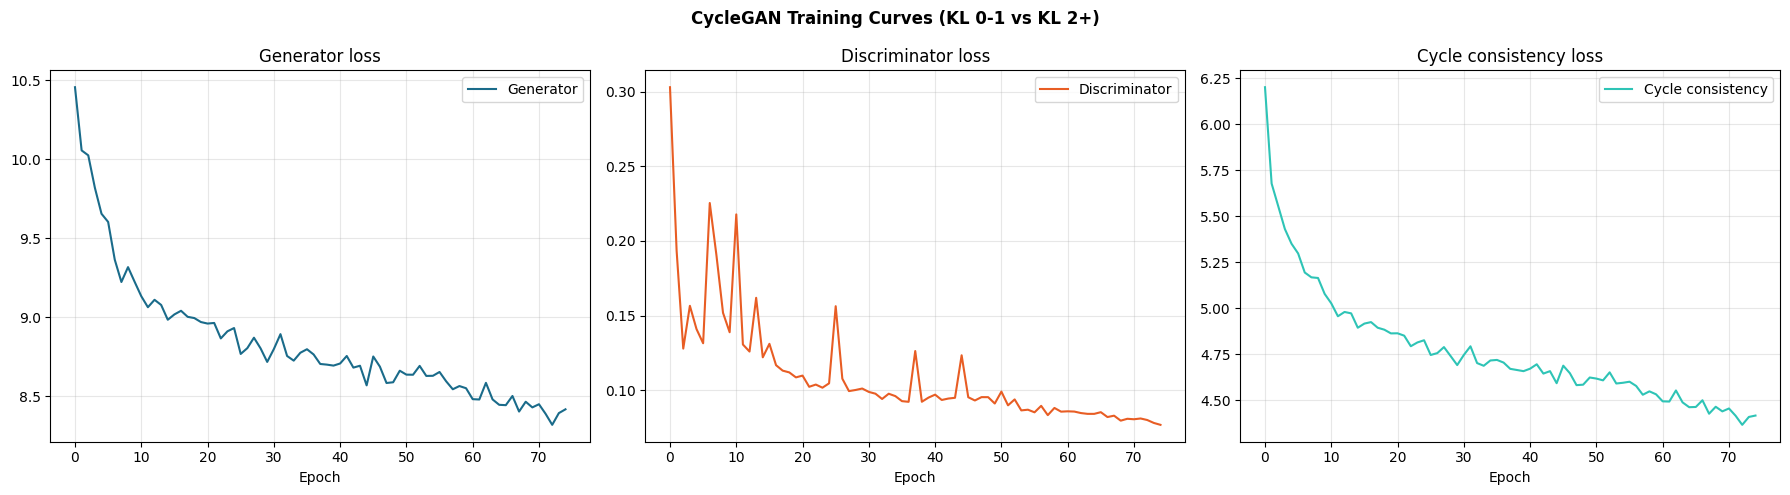

In [ ]:
# ============================================================================
# CELL 8: PLOT TRAINING CURVES
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history['g_loss'], label='Generator', color='#1A6B8A')
axes[0].set_title('Generator loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(history['d_loss'], label='Discriminator', color='#E85D24')
axes[1].set_title('Discriminator loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[2].plot(history['cycle_loss'], label='Cycle consistency', color='#2EC4B6')
axes[2].set_title('Cycle consistency loss')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)
plt.suptitle('CycleGAN Training Curves (KL 0-1 vs KL 2+)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================================
# CELL 9: GENERATE SYNTHETIC IMAGES (Zulal's corrected spec)
# ============================================================================
print('Generating synthetic images — binary healthy/diseased labels...')

np.random.seed(42)
torch.manual_seed(42)
G_AB.eval()
G_BA.eval()

# Clear old files
for folder in ['images', 'images_by_kl/kl0', 'images_by_kl/kl2plus']:
    folder_path = os.path.join(OUTPUT_DIR, folder)
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
    os.makedirs(folder_path, exist_ok=True)

manifest_rows = []
gen_count = 0

# ── 300 DISEASED (KL 2+) from healthy inputs ──
print('\nGenerating 300 diseased images from healthy inputs (G_AB)...')
healthy_paths = domain_a_df['image_path'].tolist()
selected_healthy = np.random.choice(healthy_paths, 300, replace=False)

with torch.no_grad():
    for i, path in enumerate(tqdm(selected_healthy, desc='Healthy → Diseased')):
        img = Image.open(path).convert('L')
        img_t = transform_test(img).unsqueeze(0).to(device)
        fake = G_AB(img_t)
        fake_np = denormalize(fake.squeeze().cpu()).clamp(0, 1).numpy()
        fake_img = Image.fromarray((fake_np * 255).astype(np.uint8), mode='L').resize((IMG_SIZE, IMG_SIZE))
        fname = f'cyclegan_kl2plus_{i:03d}.png'
        fake_img.save(os.path.join(OUTPUT_DIR, 'images', fname))
        fake_img.save(os.path.join(OUTPUT_DIR, 'images_by_kl', 'kl2plus', fname))
        manifest_rows.append({'filename': fname, 'KL': '2+', 'joint_type': 'DIP', 'source': 'cyclegan'})
        gen_count += 1

# ── 300 HEALTHY (KL 0-1) from diseased inputs ──
print('Generating 300 healthy images from diseased inputs (G_BA)...')
diseased_paths = domain_b_df['image_path'].tolist()
selected_diseased = np.random.choice(diseased_paths, 300, replace=len(diseased_paths) < 300)

with torch.no_grad():
    for i, path in enumerate(tqdm(selected_diseased, desc='Diseased → Healthy')):
        img = Image.open(path).convert('L')
        img_t = transform_test(img).unsqueeze(0).to(device)
        fake = G_BA(img_t)
        fake_np = denormalize(fake.squeeze().cpu()).clamp(0, 1).numpy()
        fake_img = Image.fromarray((fake_np * 255).astype(np.uint8), mode='L').resize((IMG_SIZE, IMG_SIZE))
        fname = f'cyclegan_kl01_healthy_{i:03d}.png'
        fake_img.save(os.path.join(OUTPUT_DIR, 'images', fname))
        fake_img.save(os.path.join(OUTPUT_DIR, 'images_by_kl', 'kl0', fname))
        manifest_rows.append({'filename': fname, 'KL': '0-1', 'joint_type': 'DIP', 'source': 'cyclegan'})
        gen_count += 1

manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(os.path.join(OUTPUT_DIR, 'synthetic_manifest.csv'), index=False)

gen_config = {'seed': 42, 'domain_a': 'KL 0-1 (healthy)', 'domain_b': 'KL 2+ (diseased)',
              'domain_a_size': len(domain_a_df), 'domain_b_size': len(domain_b_df),
              'generated_diseased': 300, 'generated_healthy': 300, 'total': gen_count, 'img_size': IMG_SIZE}
with open(os.path.join(OUTPUT_DIR, 'generation_config.json'), 'w') as f:
    json.dump(gen_config, f, indent=2)

print(f'\n{"="*60}')
print(f'✅ Generated {gen_count} synthetic images')
print(f'\n  Diseased (KL 2+):  {len(manifest_df[manifest_df["KL"]=="2+"])} images')
print(f'  Healthy (KL 0-1):  {len(manifest_df[manifest_df["KL"]=="0-1"])} images')
print(f'\n  synthetic_manifest.csv: {len(manifest_df)} rows')
print(f'  Seed: 42')

Generating synthetic images — binary healthy/diseased labels...

Generating 300 diseased images from healthy inputs (G_AB)...


Healthy → Diseased:   0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_5095/1515604615.py:32: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  fake_img = Image.fromarray((fake_np * 255).astype(np.uint8), mode='L').resize((IMG_SIZE, IMG_SIZE))
Healthy → Diseased: 100%|██████████| 300/300 [00:57<00:00,  5.20it/s]


Generating 300 healthy images from diseased inputs (G_BA)...


Diseased → Healthy:   0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_5095/1515604615.py:50: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  fake_img = Image.fromarray((fake_np * 255).astype(np.uint8), mode='L').resize((IMG_SIZE, IMG_SIZE))
Diseased → Healthy: 100%|██████████| 300/300 [00:54<00:00,  5.53it/s]



✅ Generated 600 synthetic images

  Diseased (KL 2+):  300 images
  Healthy (KL 0-1):  300 images

  synthetic_manifest.csv: 600 rows
  Seed: 42


Visual QC — real vs synthetic comparison


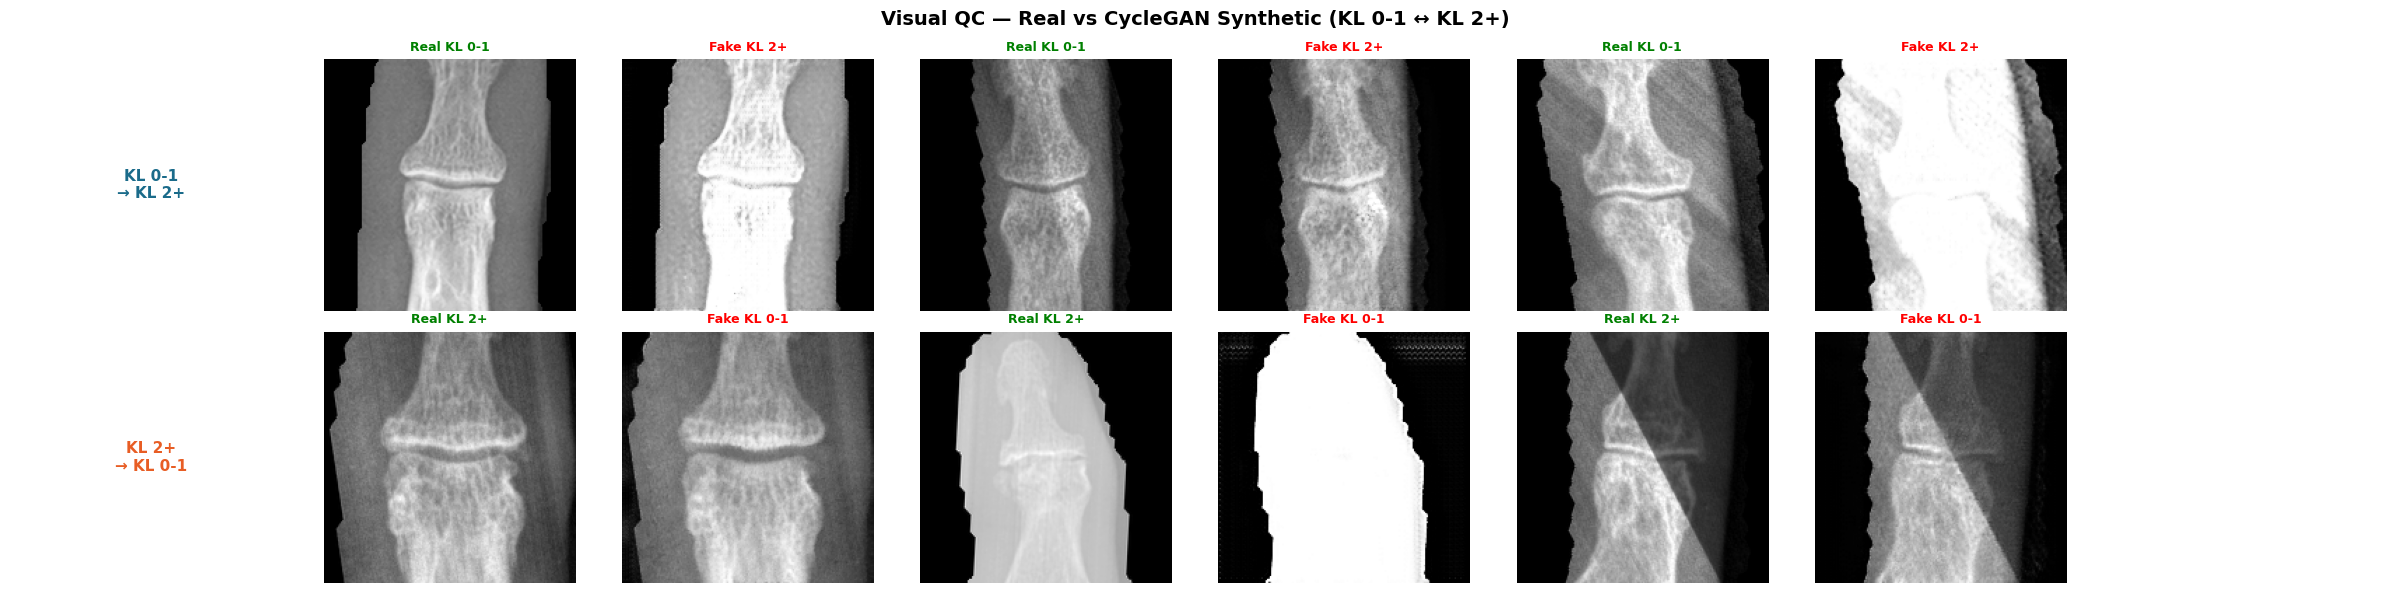


✅ Visual QC saved to: /content/drive/MyDrive/CV-Project/models/cyclegan_outputs/visual_qc.png

🎉 CycleGAN Stage 1 complete!
   Zulal can now run FID evaluation using:
   - synthetic_manifest.csv
   - images_by_kl/ folders


In [ ]:
# ============================================================================
# CELL 10: VISUAL QC — REAL vs SYNTHETIC
# ============================================================================
print('Visual QC — real vs synthetic comparison')

fig, axes = plt.subplots(2, 8, figsize=(24, 6))
fig.suptitle('Visual QC — Real vs CycleGAN Synthetic (KL 0-1 ↔ KL 2+)',
             fontsize=14, fontweight='bold')

# Row 1: Healthy → Diseased
axes[0][0].text(0.5, 0.5, 'KL 0-1\n→ KL 2+', transform=axes[0][0].transAxes,
                fontsize=11, fontweight='bold', ha='center', va='center', color='#1A6B8A')
axes[0][0].axis('off')

healthy_paths_list = domain_a_df['image_path'].tolist()
for i in range(3):
    idx = i * 50
    if idx < len(healthy_paths_list):
        img = Image.open(healthy_paths_list[idx]).convert('L')
        img_t = transform_test(img).unsqueeze(0).to(device)
        with torch.no_grad():
            fake = G_AB(img_t)
        real_np = np.array(img.resize((IMG_SIZE, IMG_SIZE)))
        fake_np = (denormalize(fake.squeeze().cpu()).clamp(0, 1).numpy() * 255).astype(np.uint8)
        axes[0][i*2 + 1].imshow(real_np, cmap='gray')
        axes[0][i*2 + 1].set_title('Real KL 0-1', fontsize=9, color='green', fontweight='bold')
        axes[0][i*2 + 1].axis('off')
        axes[0][i*2 + 2].imshow(fake_np, cmap='gray')
        axes[0][i*2 + 2].set_title('Fake KL 2+', fontsize=9, color='red', fontweight='bold')
        axes[0][i*2 + 2].axis('off')

axes[0][7].axis('off')

# Row 2: Diseased → Healthy
axes[1][0].text(0.5, 0.5, 'KL 2+\n→ KL 0-1', transform=axes[1][0].transAxes,
                fontsize=11, fontweight='bold', ha='center', va='center', color='#E85D24')
axes[1][0].axis('off')

diseased_paths_list = domain_b_df['image_path'].tolist()
for i in range(3):
    idx = i * 30
    if idx < len(diseased_paths_list):
        img = Image.open(diseased_paths_list[idx]).convert('L')
        img_t = transform_test(img).unsqueeze(0).to(device)
        with torch.no_grad():
            fake = G_BA(img_t)
        real_np = np.array(img.resize((IMG_SIZE, IMG_SIZE)))
        fake_np = (denormalize(fake.squeeze().cpu()).clamp(0, 1).numpy() * 255).astype(np.uint8)
        axes[1][i*2 + 1].imshow(real_np, cmap='gray')
        axes[1][i*2 + 1].set_title('Real KL 2+', fontsize=9, color='green', fontweight='bold')
        axes[1][i*2 + 1].axis('off')
        axes[1][i*2 + 2].imshow(fake_np, cmap='gray')
        axes[1][i*2 + 2].set_title('Fake KL 0-1', fontsize=9, color='red', fontweight='bold')
        axes[1][i*2 + 2].axis('off')

axes[1][7].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'visual_qc.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅ Visual QC saved to: {OUTPUT_DIR}/visual_qc.png')
print(f'\n🎉 CycleGAN Stage 1 complete!')
print(f'   Zulal can now run FID evaluation using:')
print(f'   - synthetic_manifest.csv')
print(f'   - images_by_kl/ folders')

Running evaluation on v2 model...
Validation samples: 200 healthy, 200 diseased

1. CYCLE RECONSTRUCTION QUALITY
----------------------------------------


Cycle B: 100%|██████████| 200/200 [00:54<00:00,  3.65it/s]



  Cycle A (Healthy → Diseased → Healthy):
    MSE:  0.010177 ± 0.016696
    MAE:  0.053659 ± 0.047329
    PSNR: 24.17 ± 6.29 dB
    SSIM: 0.9212 ± 0.0770

  Cycle B (Diseased → Healthy → Diseased):
    MSE:  0.010751 ± 0.016243
    MAE:  0.053565 ± 0.044923
    PSNR: 23.49 ± 5.96 dB
    SSIM: 0.9108 ± 0.0881

2. TRANSLATION QUALITY
----------------------------------------
  Healthy → Diseased SSIM: 0.8332 ± 0.1559
  Diseased → Healthy SSIM: 0.7819 ± 0.1827

3. DISCRIMINATOR CONFIDENCE
----------------------------------------


D scores: 100%|██████████| 200/200 [00:31<00:00,  6.34it/s]


  Domain A: Real=0.9516, Fake=0.1586, Gap=0.7930 (83.3%)
  Domain B: Real=0.9080, Fake=0.0357, Gap=0.8722 (96.1%)

  EVALUATION SUMMARY — CycleGAN v2 (KL 0-1 vs KL 2+)
  Cycle SSIM (Healthy)                    0.9212   target: > 0.80
  Cycle SSIM (Diseased)                   0.9108   target: > 0.80
  Cycle PSNR (Healthy)                  24.17 dB   target: > 20 dB
  Cycle PSNR (Diseased)                 23.49 dB   target: > 20 dB
  Cycle MSE (Healthy)                   0.010177   target: < 0.01
  Cycle MSE (Diseased)                  0.010751   target: < 0.01
  Translation SSIM (H→D)                  0.8332   target: 0.5–0.85
  Translation SSIM (D→H)                  0.7819   target: 0.5–0.85
  Discriminator gap (A)                    83.3%   target: < 10%
  Discriminator gap (B)                    96.1%   target: < 10%
  Generator final loss                    8.4182   target: —
  Cycle final loss                        4.4179   target: —
  Training epochs                 75 (converge

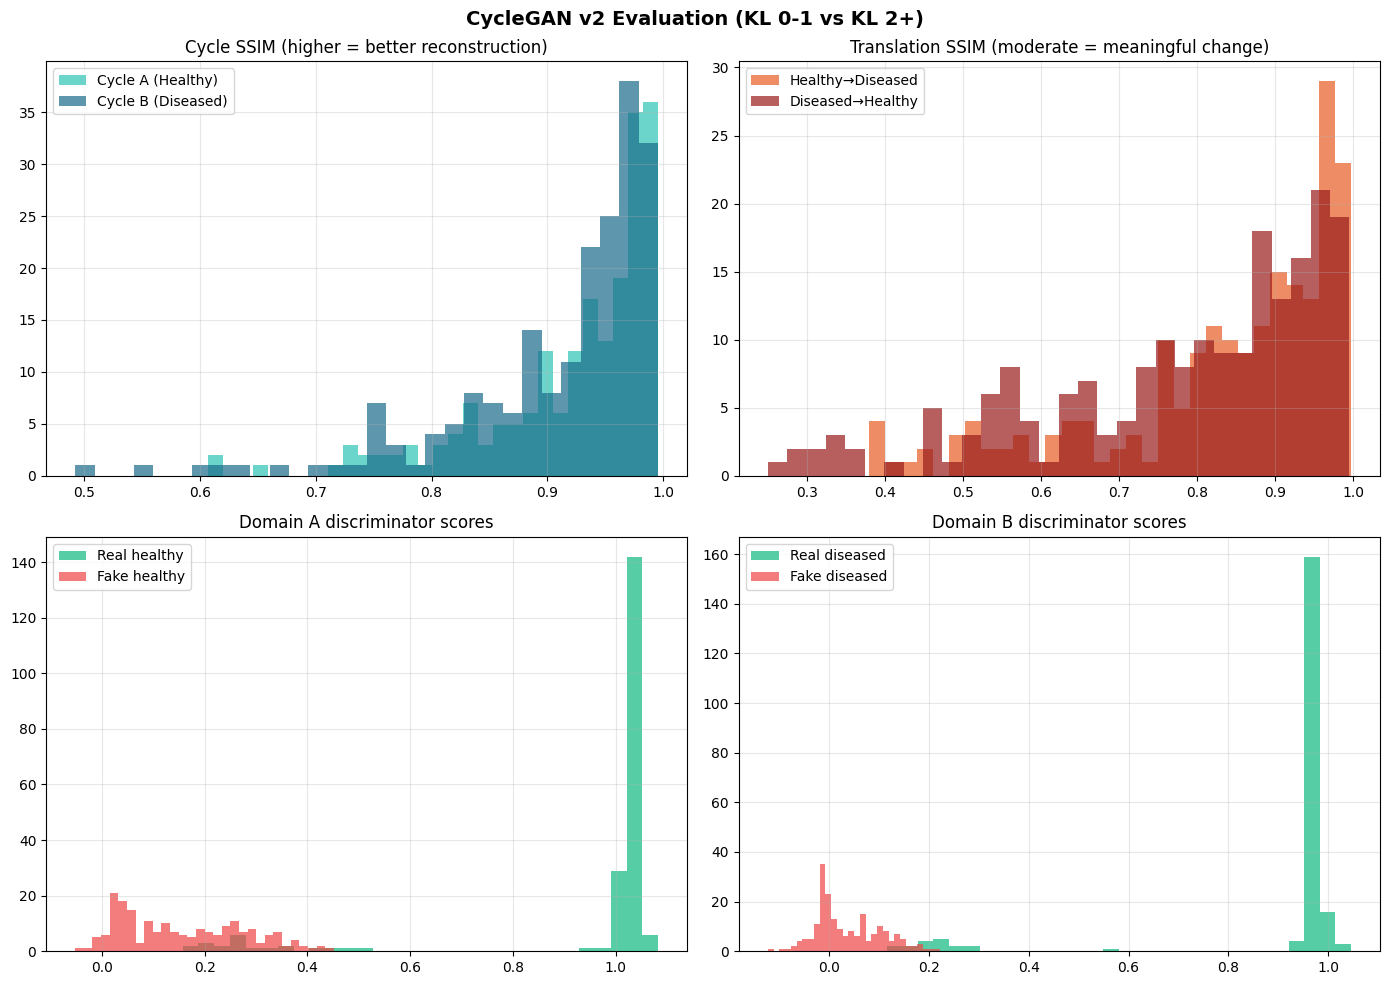

✅ Saved: evaluation_plots_v2.png


In [ ]:
# ============================================================================
# COMPREHENSIVE EVALUATION — CycleGAN v2 (KL 0-1 vs KL 2+)
# ============================================================================
print("Running evaluation on v2 model...")
print("=" * 60)

G_AB.eval()
G_BA.eval()
D_A.eval()
D_B.eval()

# Load validation set
val = df[df['split'] == 'val'].copy()
val_healthy = val[val[kl_col] <= 1].sample(min(200, len(val[val[kl_col]<=1])), random_state=42)
val_diseased = val[val[kl_col] >= 2].sample(min(200, len(val[val[kl_col]>=2])), random_state=42)

print(f"Validation samples: {len(val_healthy)} healthy, {len(val_diseased)} diseased")

# ── 1. CYCLE RECONSTRUCTION METRICS ──
print("\n1. CYCLE RECONSTRUCTION QUALITY")
print("-" * 40)

mse_a, mae_a, psnr_a, ssim_a = [], [], [], []
mse_b, mae_b, psnr_b, ssim_b = [], [], [], []
trans_ssim_ab, trans_ssim_ba = [], []

def compute_ssim(img1, img2):
    C1, C2 = 0.01**2, 0.03**2
    mu1, mu2 = np.mean(img1), np.mean(img2)
    s1, s2 = np.var(img1), np.var(img2)
    s12 = np.mean((img1 - mu1) * (img2 - mu2))
    return ((2*mu1*mu2+C1)*(2*s12+C2)) / ((mu1**2+mu2**2+C1)*(s1+s2+C2))

with torch.no_grad():
    for _, row in tqdm(val_healthy.iterrows(), total=len(val_healthy), desc="Cycle A"):
        img = Image.open(row['image_path']).convert('L')
        img_t = transform_test(img).unsqueeze(0).to(device)
        fake_b = G_AB(img_t)
        recon_a = G_BA(fake_b)

        orig = denormalize(img_t.squeeze().cpu()).clamp(0,1).numpy()
        fake = denormalize(fake_b.squeeze().cpu()).clamp(0,1).numpy()
        recon = denormalize(recon_a.squeeze().cpu()).clamp(0,1).numpy()

        m = np.mean((orig - recon)**2)
        mse_a.append(m)
        mae_a.append(np.mean(np.abs(orig - recon)))
        psnr_a.append(10 * np.log10(1.0 / (m + 1e-10)))
        ssim_a.append(compute_ssim(orig, recon))
        trans_ssim_ab.append(compute_ssim(orig, fake))

    for _, row in tqdm(val_diseased.iterrows(), total=len(val_diseased), desc="Cycle B"):
        img = Image.open(row['image_path']).convert('L')
        img_t = transform_test(img).unsqueeze(0).to(device)
        fake_a = G_BA(img_t)
        recon_b = G_AB(fake_a)

        orig = denormalize(img_t.squeeze().cpu()).clamp(0,1).numpy()
        fake = denormalize(fake_a.squeeze().cpu()).clamp(0,1).numpy()
        recon = denormalize(recon_b.squeeze().cpu()).clamp(0,1).numpy()

        m = np.mean((orig - recon)**2)
        mse_b.append(m)
        mae_b.append(np.mean(np.abs(orig - recon)))
        psnr_b.append(10 * np.log10(1.0 / (m + 1e-10)))
        ssim_b.append(compute_ssim(orig, recon))
        trans_ssim_ba.append(compute_ssim(orig, fake))

print(f"\n  Cycle A (Healthy → Diseased → Healthy):")
print(f"    MSE:  {np.mean(mse_a):.6f} ± {np.std(mse_a):.6f}")
print(f"    MAE:  {np.mean(mae_a):.6f} ± {np.std(mae_a):.6f}")
print(f"    PSNR: {np.mean(psnr_a):.2f} ± {np.std(psnr_a):.2f} dB")
print(f"    SSIM: {np.mean(ssim_a):.4f} ± {np.std(ssim_a):.4f}")

print(f"\n  Cycle B (Diseased → Healthy → Diseased):")
print(f"    MSE:  {np.mean(mse_b):.6f} ± {np.std(mse_b):.6f}")
print(f"    MAE:  {np.mean(mae_b):.6f} ± {np.std(mae_b):.6f}")
print(f"    PSNR: {np.mean(psnr_b):.2f} ± {np.std(psnr_b):.2f} dB")
print(f"    SSIM: {np.mean(ssim_b):.4f} ± {np.std(ssim_b):.4f}")

# ── 2. TRANSLATION SSIM ──
print(f"\n2. TRANSLATION QUALITY")
print("-" * 40)
print(f"  Healthy → Diseased SSIM: {np.mean(trans_ssim_ab):.4f} ± {np.std(trans_ssim_ab):.4f}")
print(f"  Diseased → Healthy SSIM: {np.mean(trans_ssim_ba):.4f} ± {np.std(trans_ssim_ba):.4f}")

# ── 3. DISCRIMINATOR CONFIDENCE ──
print(f"\n3. DISCRIMINATOR CONFIDENCE")
print("-" * 40)

real_a_scores, fake_a_scores = [], []
real_b_scores, fake_b_scores = [], []

with torch.no_grad():
    for _, row in tqdm(val_healthy.iterrows(), total=len(val_healthy), desc="D scores"):
        img = Image.open(row['image_path']).convert('L')
        img_t = transform_test(img).unsqueeze(0).to(device)
        real_a_scores.append(D_A(img_t).mean().item())
        fake_b_scores.append(D_B(G_AB(img_t)).mean().item())

    for _, row in tqdm(val_diseased.iterrows(), total=len(val_diseased), desc="D scores"):
        img = Image.open(row['image_path']).convert('L')
        img_t = transform_test(img).unsqueeze(0).to(device)
        real_b_scores.append(D_B(img_t).mean().item())
        fake_a_scores.append(D_A(G_BA(img_t)).mean().item())

gap_a = abs(np.mean(real_a_scores) - np.mean(fake_a_scores))
gap_b = abs(np.mean(real_b_scores) - np.mean(fake_b_scores))

print(f"  Domain A: Real={np.mean(real_a_scores):.4f}, Fake={np.mean(fake_a_scores):.4f}, Gap={gap_a:.4f} ({gap_a/abs(np.mean(real_a_scores))*100:.1f}%)")
print(f"  Domain B: Real={np.mean(real_b_scores):.4f}, Fake={np.mean(fake_b_scores):.4f}, Gap={gap_b:.4f} ({gap_b/abs(np.mean(real_b_scores))*100:.1f}%)")

# ── 4. SUMMARY TABLE ──
print(f"\n{'='*60}")
print(f"  EVALUATION SUMMARY — CycleGAN v2 (KL 0-1 vs KL 2+)")
print(f"{'='*60}")

results = {
    'Cycle SSIM (Healthy)': f"{np.mean(ssim_a):.4f}",
    'Cycle SSIM (Diseased)': f"{np.mean(ssim_b):.4f}",
    'Cycle PSNR (Healthy)': f"{np.mean(psnr_a):.2f} dB",
    'Cycle PSNR (Diseased)': f"{np.mean(psnr_b):.2f} dB",
    'Cycle MSE (Healthy)': f"{np.mean(mse_a):.6f}",
    'Cycle MSE (Diseased)': f"{np.mean(mse_b):.6f}",
    'Translation SSIM (H→D)': f"{np.mean(trans_ssim_ab):.4f}",
    'Translation SSIM (D→H)': f"{np.mean(trans_ssim_ba):.4f}",
    'Discriminator gap (A)': f"{gap_a/abs(np.mean(real_a_scores))*100:.1f}%",
    'Discriminator gap (B)': f"{gap_b/abs(np.mean(real_b_scores))*100:.1f}%",
    'Generator final loss': f"{history['g_loss'][-1]:.4f}",
    'Cycle final loss': f"{history['cycle_loss'][-1]:.4f}",
    'Training epochs': '75 (converged)',
    'Training time': f"{sum(history['epoch_time'])/60:.1f} min",
    'Images generated': '600 (300 diseased + 300 healthy)',
}

targets = {
    'Cycle SSIM (Healthy)': '> 0.80',
    'Cycle SSIM (Diseased)': '> 0.80',
    'Cycle PSNR (Healthy)': '> 20 dB',
    'Cycle PSNR (Diseased)': '> 20 dB',
    'Cycle MSE (Healthy)': '< 0.01',
    'Cycle MSE (Diseased)': '< 0.01',
    'Translation SSIM (H→D)': '0.5–0.85',
    'Translation SSIM (D→H)': '0.5–0.85',
    'Discriminator gap (A)': '< 10%',
    'Discriminator gap (B)': '< 10%',
}

for metric, value in results.items():
    target = targets.get(metric, '—')
    print(f"  {metric:30s} {value:>15s}   target: {target}")

# Save
eval_df = pd.DataFrame([{'Metric': k, 'Value': v, 'Target': targets.get(k, '—')} for k, v in results.items()])
eval_df.to_csv(os.path.join(OUTPUT_DIR, 'evaluation_summary_v2.csv'), index=False)
print(f"\n✅ Saved: evaluation_summary_v2.csv")

# ── 5. VISUALIZATION ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].hist(ssim_a, bins=30, alpha=0.7, color='#2EC4B6', label='Cycle A (Healthy)')
axes[0][0].hist(ssim_b, bins=30, alpha=0.7, color='#1A6B8A', label='Cycle B (Diseased)')
axes[0][0].set_title('Cycle SSIM (higher = better reconstruction)')
axes[0][0].legend()
axes[0][0].grid(alpha=0.3)

axes[0][1].hist(trans_ssim_ab, bins=30, alpha=0.7, color='#E85D24', label='Healthy→Diseased')
axes[0][1].hist(trans_ssim_ba, bins=30, alpha=0.7, color='#991B1B', label='Diseased→Healthy')
axes[0][1].set_title('Translation SSIM (moderate = meaningful change)')
axes[0][1].legend()
axes[0][1].grid(alpha=0.3)

axes[1][0].hist(real_a_scores, bins=30, alpha=0.7, color='#10B981', label='Real healthy')
axes[1][0].hist(fake_a_scores, bins=30, alpha=0.7, color='#EF4444', label='Fake healthy')
axes[1][0].set_title('Domain A discriminator scores')
axes[1][0].legend()
axes[1][0].grid(alpha=0.3)

axes[1][1].hist(real_b_scores, bins=30, alpha=0.7, color='#10B981', label='Real diseased')
axes[1][1].hist(fake_b_scores, bins=30, alpha=0.7, color='#EF4444', label='Fake diseased')
axes[1][1].set_title('Domain B discriminator scores')
axes[1][1].legend()
axes[1][1].grid(alpha=0.3)

plt.suptitle('CycleGAN v2 Evaluation (KL 0-1 vs KL 2+)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'evaluation_plots_v2.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: evaluation_plots_v2.png")

In [ ]:
# Clean up old folders from first run
import shutil
for old in ['kl1', 'kl2', 'kl3', 'kl4']:
    path = os.path.join(OUTPUT_DIR, 'images_by_kl', old)
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f"Deleted old folder: {old}/")

# Verify final structure
print("\nFinal output structure:")
for root, dirs, files in os.walk(OUTPUT_DIR):
    depth = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")

Deleted old folder: kl2/
Deleted old folder: kl3/
Deleted old folder: kl4/

Final output structure:
cyclegan_outputs/  (12 files)
  training_samples/  (11 files)
  images_by_kl/  (0 files)
    kl0/  (300 files)
    kl2plus/  (300 files)
  images/  (600 files)


In [ ]:
# Fix manifest labels for Zulal's pipeline
manifest_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'synthetic_manifest.csv'))

# Replace string labels with integers
# KL 2+ → label as 2 (since CycleGAN can't distinguish 2/3/4)
# KL 0-1 → label as 0 (since CycleGAN can't distinguish 0/1)
manifest_df['KL'] = manifest_df['KL'].replace({'2+': 2, '0-1': 0})

manifest_df.to_csv(os.path.join(OUTPUT_DIR, 'synthetic_manifest.csv'), index=False)

print("Fixed manifest:")
print(manifest_df['KL'].value_counts())
print(f"\nSample rows:")
print(manifest_df.head())

Fixed manifest:
KL
2    300
0    300
Name: count, dtype: int64

Sample rows:
                   filename  KL joint_type    source
0  cyclegan_kl2plus_000.png   2        DIP  cyclegan
1  cyclegan_kl2plus_001.png   2        DIP  cyclegan
2  cyclegan_kl2plus_002.png   2        DIP  cyclegan
3  cyclegan_kl2plus_003.png   2        DIP  cyclegan
4  cyclegan_kl2plus_004.png   2        DIP  cyclegan


/tmp/ipykernel_5095/492856623.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  manifest_df['KL'] = manifest_df['KL'].replace({'2+': 2, '0-1': 0})


In [ ]:
# ============================================================================
# GENERATE ALL DIAGRAMS FOR TEAM PRESENTATION
# Run this AFTER the reload cell (models loaded, images extracted)
# ============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

G_AB.eval()
G_BA.eval()

IMG_SIZE = 180
save_dir = os.path.join(OUTPUT_DIR, 'presentation_diagrams')
os.makedirs(save_dir, exist_ok=True)

print("Generating all presentation diagrams...")
print("=" * 60)

# ════════════════════════════════════════════════════════════
# DIAGRAM 1: SLIDE 10 — Real → Fake → Reconstructed
# ════════════════════════════════════════════════════════════
print("\n1. Slide 10 — CycleGAN samples...")

healthy_paths = domain_a_df['image_path'].tolist()
diseased_paths = domain_b_df['image_path'].tolist()

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('CycleGAN — Real → Generated → Reconstructed', fontsize=16, fontweight='bold')

# Row 1: Healthy → Diseased → Recon Healthy (2 triplets)
titles_row1 = ['Real KL 0-1', 'Fake KL 2+', 'Recon KL 0-1', 'Real KL 0-1', 'Fake KL 2+', 'Recon KL 0-1']
colors_row1 = ['green', 'red', 'blue', 'green', 'red', 'blue']

sample_idx_a = [0, 100]  # two different healthy inputs
col = 0
for idx in sample_idx_a:
    if idx >= len(healthy_paths):
        idx = 0
    img = Image.open(healthy_paths[idx]).convert('L')
    img_t = transform_test(img).unsqueeze(0).to(device)
    with torch.no_grad():
        fake_b = G_AB(img_t)
        recon_a = G_BA(fake_b)

    real_np = np.array(img.resize((IMG_SIZE, IMG_SIZE)))
    fake_np = (denormalize(fake_b.squeeze().cpu()).clamp(0, 1).numpy() * 255).astype(np.uint8)
    recon_np = (denormalize(recon_a.squeeze().cpu()).clamp(0, 1).numpy() * 255).astype(np.uint8)

    axes[0][col].imshow(real_np, cmap='gray'); axes[0][col].axis('off')
    axes[0][col].set_title(titles_row1[col], fontsize=9, color=colors_row1[col], fontweight='bold')
    col += 1
    axes[0][col].imshow(fake_np, cmap='gray'); axes[0][col].axis('off')
    axes[0][col].set_title(titles_row1[col], fontsize=9, color=colors_row1[col], fontweight='bold')
    col += 1
    axes[0][col].imshow(recon_np, cmap='gray'); axes[0][col].axis('off')
    axes[0][col].set_title(titles_row1[col], fontsize=9, color=colors_row1[col], fontweight='bold')
    col += 1

# Row 2: Diseased → Healthy → Recon Diseased (2 triplets)
titles_row2 = ['Real KL 2+', 'Fake KL 0-1', 'Recon KL 2+', 'Real KL 2+', 'Fake KL 0-1', 'Recon KL 2+']
colors_row2 = ['green', 'red', 'blue', 'green', 'red', 'blue']

sample_idx_b = [0, 50]
col = 0
for idx in sample_idx_b:
    if idx >= len(diseased_paths):
        idx = 0
    img = Image.open(diseased_paths[idx]).convert('L')
    img_t = transform_test(img).unsqueeze(0).to(device)
    with torch.no_grad():
        fake_a = G_BA(img_t)
        recon_b = G_AB(fake_a)

    real_np = np.array(img.resize((IMG_SIZE, IMG_SIZE)))
    fake_np = (denormalize(fake_a.squeeze().cpu()).clamp(0, 1).numpy() * 255).astype(np.uint8)
    recon_np = (denormalize(recon_b.squeeze().cpu()).clamp(0, 1).numpy() * 255).astype(np.uint8)

    axes[1][col].imshow(real_np, cmap='gray'); axes[1][col].axis('off')
    axes[1][col].set_title(titles_row2[col], fontsize=9, color=colors_row2[col], fontweight='bold')
    col += 1
    axes[1][col].imshow(fake_np, cmap='gray'); axes[1][col].axis('off')
    axes[1][col].set_title(titles_row2[col], fontsize=9, color=colors_row2[col], fontweight='bold')
    col += 1
    axes[1][col].imshow(recon_np, cmap='gray'); axes[1][col].axis('off')
    axes[1][col].set_title(titles_row2[col], fontsize=9, color=colors_row2[col], fontweight='bold')
    col += 1

axes[0][0].set_ylabel('Healthy → Diseased', fontsize=11, fontweight='bold')
axes[1][0].set_ylabel('Diseased → Healthy', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'slide10_cyclegan_samples.png'), dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print("  ✅ slide10_cyclegan_samples.png")


# ════════════════════════════════════════════════════════════
# DIAGRAM 2: TRAINING CURVES (for new slide 11A)
# ════════════════════════════════════════════════════════════
print("\n2. Training curves...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['g_loss'], color='#1A6B8A', linewidth=2)
axes[0].set_title('Generator loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].text(0.95, 0.95, f'10.46 → {history["g_loss"][-1]:.2f}\n↓ 20%',
             transform=axes[0].transAxes, fontsize=11, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='#E6F1FB', alpha=0.8))
axes[0].grid(alpha=0.3)

axes[1].plot(history['d_loss'], color='#E85D24', linewidth=2)
axes[1].set_title('Discriminator loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].text(0.95, 0.95, f'Stable at {history["d_loss"][-1]:.3f}\nNo collapse',
             transform=axes[1].transAxes, fontsize=11, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='#FFF7ED', alpha=0.8))
axes[1].grid(alpha=0.3)

axes[2].plot(history['cycle_loss'], color='#2EC4B6', linewidth=2)
axes[2].set_title('Cycle consistency loss', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].text(0.95, 0.95, f'6.20 → {history["cycle_loss"][-1]:.2f}\n↓ 29%',
             transform=axes[2].transAxes, fontsize=11, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='#E0F7F5', alpha=0.8))
axes[2].grid(alpha=0.3)

plt.suptitle('CycleGAN v2 Training Curves — 75 epochs (KL 0-1 vs KL 2+)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'slide11a_training_curves.png'), dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print("  ✅ slide11a_training_curves.png")


# ════════════════════════════════════════════════════════════
# DIAGRAM 3: REAL vs SYNTHETIC SIDE-BY-SIDE (for slide 11C)
# ════════════════════════════════════════════════════════════
print("\n3. Real vs synthetic side-by-side...")

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('Real vs CycleGAN synthetic — DIP joints', fontsize=14, fontweight='bold')

# Row 1: Healthy → Diseased (4 pairs)
for i in range(4):
    idx = i * 150
    if idx >= len(healthy_paths):
        idx = i
    img = Image.open(healthy_paths[idx]).convert('L')
    img_t = transform_test(img).unsqueeze(0).to(device)
    with torch.no_grad():
        fake = G_AB(img_t)

    real_np = np.array(img.resize((IMG_SIZE, IMG_SIZE)))
    fake_np = (denormalize(fake.squeeze().cpu()).clamp(0, 1).numpy() * 255).astype(np.uint8)

    axes[0][i*2].imshow(real_np, cmap='gray')
    axes[0][i*2].set_title('Real KL 0-1', fontsize=8, color='green', fontweight='bold')
    axes[0][i*2].axis('off')

    axes[0][i*2+1].imshow(fake_np, cmap='gray')
    axes[0][i*2+1].set_title('→ Fake KL 2+', fontsize=8, color='red', fontweight='bold')
    axes[0][i*2+1].axis('off')

# Row 2: Diseased → Healthy (4 pairs)
for i in range(4):
    idx = i * 50
    if idx >= len(diseased_paths):
        idx = i
    img = Image.open(diseased_paths[idx]).convert('L')
    img_t = transform_test(img).unsqueeze(0).to(device)
    with torch.no_grad():
        fake = G_BA(img_t)

    real_np = np.array(img.resize((IMG_SIZE, IMG_SIZE)))
    fake_np = (denormalize(fake.squeeze().cpu()).clamp(0, 1).numpy() * 255).astype(np.uint8)

    axes[1][i*2].imshow(real_np, cmap='gray')
    axes[1][i*2].set_title('Real KL 2+', fontsize=8, color='green', fontweight='bold')
    axes[1][i*2].axis('off')

    axes[1][i*2+1].imshow(fake_np, cmap='gray')
    axes[1][i*2+1].set_title('→ Fake KL 0-1', fontsize=8, color='red', fontweight='bold')
    axes[1][i*2+1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'slide11c_real_vs_synthetic.png'), dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print("  ✅ slide11c_real_vs_synthetic.png")


# ════════════════════════════════════════════════════════════
# DIAGRAM 4: EVALUATION METRICS VISUAL (for slide 11D)
# ════════════════════════════════════════════════════════════
print("\n4. Evaluation metrics visual...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# SSIM bars
metrics_names = ['Cycle SSIM\n(Healthy)', 'Cycle SSIM\n(Diseased)', 'Translation\n(H→D)', 'Translation\n(D→H)']
metrics_vals = [0.9212, 0.9108, 0.8332, 0.7819]
colors = ['#2EC4B6', '#1A6B8A', '#E85D24', '#991B1B']

bars = axes[0].bar(metrics_names, metrics_vals, color=colors, width=0.55)
axes[0].axhline(y=0.80, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Min target (0.80)')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('SSIM scores', fontsize=14, fontweight='bold')
for bar, val in zip(bars, metrics_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# PSNR bars
psnr_names = ['Cycle A\n(Healthy)', 'Cycle B\n(Diseased)']
psnr_vals = [24.17, 23.49]
psnr_colors = ['#2EC4B6', '#1A6B8A']

bars2 = axes[1].bar(psnr_names, psnr_vals, color=psnr_colors, width=0.45)
axes[1].axhline(y=20, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Min target (20 dB)')
axes[1].set_ylim(0, 28)
axes[1].set_title('PSNR (dB)', fontsize=14, fontweight='bold')
for bar, val in zip(bars2, psnr_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4, f'{val:.2f} dB',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Summary scorecard
axes[2].axis('off')
scorecard = [
    ('Cycle SSIM', '0.92 / 0.91', '> 0.80', '✅'),
    ('PSNR', '24.2 / 23.5 dB', '> 20 dB', '✅'),
    ('Translation SSIM', '0.83 / 0.78', '0.5–0.85', '✅'),
    ('Disc. gap', '83% / 96%', '< 10%', '⚠️'),
    ('Mode collapse', 'None', '—', '✅'),
    ('Images generated', '600', '300+', '✅'),
    ('Epochs', '75', '100', '⚠️'),
]

axes[2].text(0.5, 0.97, 'Results scorecard', fontsize=14, fontweight='bold',
             ha='center', transform=axes[2].transAxes, color='#0B3D5C')

for i, (metric, value, target, status) in enumerate(scorecard):
    y = 0.85 - i * 0.11
    bg = '#F0FFF4' if status == '✅' else '#FFF7ED'
    axes[2].add_patch(plt.Rectangle((0.02, y - 0.04), 0.96, 0.09, transform=axes[2].transAxes,
                                     facecolor=bg, edgecolor='#E2E8F0', linewidth=0.5))
    axes[2].text(0.05, y, metric, fontsize=10, transform=axes[2].transAxes, color='#333333')
    axes[2].text(0.52, y, value, fontsize=10, fontweight='bold', transform=axes[2].transAxes, color='#1A6B8A')
    axes[2].text(0.78, y, target, fontsize=9, transform=axes[2].transAxes, color='#666666')
    axes[2].text(0.95, y, status, fontsize=12, transform=axes[2].transAxes, ha='center')

plt.suptitle('CycleGAN v2 — Evaluation Summary', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'slide11d_evaluation_metrics.png'), dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print("  ✅ slide11d_evaluation_metrics.png")


# ════════════════════════════════════════════════════════════
# DIAGRAM 5: FOR SLIDE 27 — Visual comparison for quality check
# ════════════════════════════════════════════════════════════
print("\n5. Slide 27 — Visual comparison for quality check...")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('CycleGAN — Quality check: Real vs Generated', fontsize=14, fontweight='bold')

axes[0][0].set_ylabel('Real\n(input)', fontsize=11, fontweight='bold')
axes[1][0].set_ylabel('CycleGAN\n(output)', fontsize=11, fontweight='bold')

for i in range(5):
    idx = i * 120
    if idx >= len(healthy_paths):
        idx = i * 10
    img = Image.open(healthy_paths[idx]).convert('L')
    img_t = transform_test(img).unsqueeze(0).to(device)
    with torch.no_grad():
        fake = G_AB(img_t)

    real_np = np.array(img.resize((IMG_SIZE, IMG_SIZE)))
    fake_np = (denormalize(fake.squeeze().cpu()).clamp(0, 1).numpy() * 255).astype(np.uint8)

    axes[0][i].imshow(real_np, cmap='gray')
    axes[0][i].set_title(f'KL 0-1 (real)', fontsize=9, color='green')
    axes[0][i].axis('off')

    axes[1][i].imshow(fake_np, cmap='gray')
    axes[1][i].set_title(f'→ KL 2+ (fake)', fontsize=9, color='red')
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'slide27_visual_comparison.png'), dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print("  ✅ slide27_visual_comparison.png")


# ════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"✅ ALL DIAGRAMS SAVED to: {save_dir}/")
print(f"{'='*60}")

for f in sorted(os.listdir(save_dir)):
    if f.endswith('.png'):
        size = os.path.getsize(os.path.join(save_dir, f)) / 1024
        print(f"  📄 {f} — {size:.0f} KB")

print(f"\nPaste these into Google Slides:")
print(f"  • slide10_cyclegan_samples.png → Slide 10 (replace placeholder)")
print(f"  • slide11a_training_curves.png → NEW slide after 10 (training curves)")
print(f"  • slide11c_real_vs_synthetic.png → NEW slide (real vs fake comparison)")
print(f"  • slide11d_evaluation_metrics.png → NEW slide (metrics + scorecard)")
print(f"  • slide27_visual_comparison.png → Slide 27 (quality check section)")

Generating all presentation diagrams...

1. Slide 10 — CycleGAN samples...
  ✅ slide10_cyclegan_samples.png

2. Training curves...
  ✅ slide11a_training_curves.png

3. Real vs synthetic side-by-side...
  ✅ slide11c_real_vs_synthetic.png

4. Evaluation metrics visual...


/tmp/ipykernel_10428/485008077.py:259: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10428/485008077.py:260: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(save_dir, 'slide11d_evaluation_metrics.png'), dpi=200, bbox_inches='tight', facecolor='white')


  ✅ slide11d_evaluation_metrics.png

5. Slide 27 — Visual comparison for quality check...
  ✅ slide27_visual_comparison.png

✅ ALL DIAGRAMS SAVED to: /content/drive/MyDrive/CV-Project/models/cyclegan_outputs/presentation_diagrams/
  📄 slide10_cyclegan_samples.png — 1290 KB
  📄 slide11a_training_curves.png — 217 KB
  📄 slide11c_real_vs_synthetic.png — 1294 KB
  📄 slide11d_evaluation_metrics.png — 171 KB
  📄 slide27_visual_comparison.png — 840 KB

Paste these into Google Slides:
  • slide10_cyclegan_samples.png → Slide 10 (replace placeholder)
  • slide11a_training_curves.png → NEW slide after 10 (training curves)
  • slide11c_real_vs_synthetic.png → NEW slide (real vs fake comparison)
  • slide11d_evaluation_metrics.png → NEW slide (metrics + scorecard)
  • slide27_visual_comparison.png → Slide 27 (quality check section)


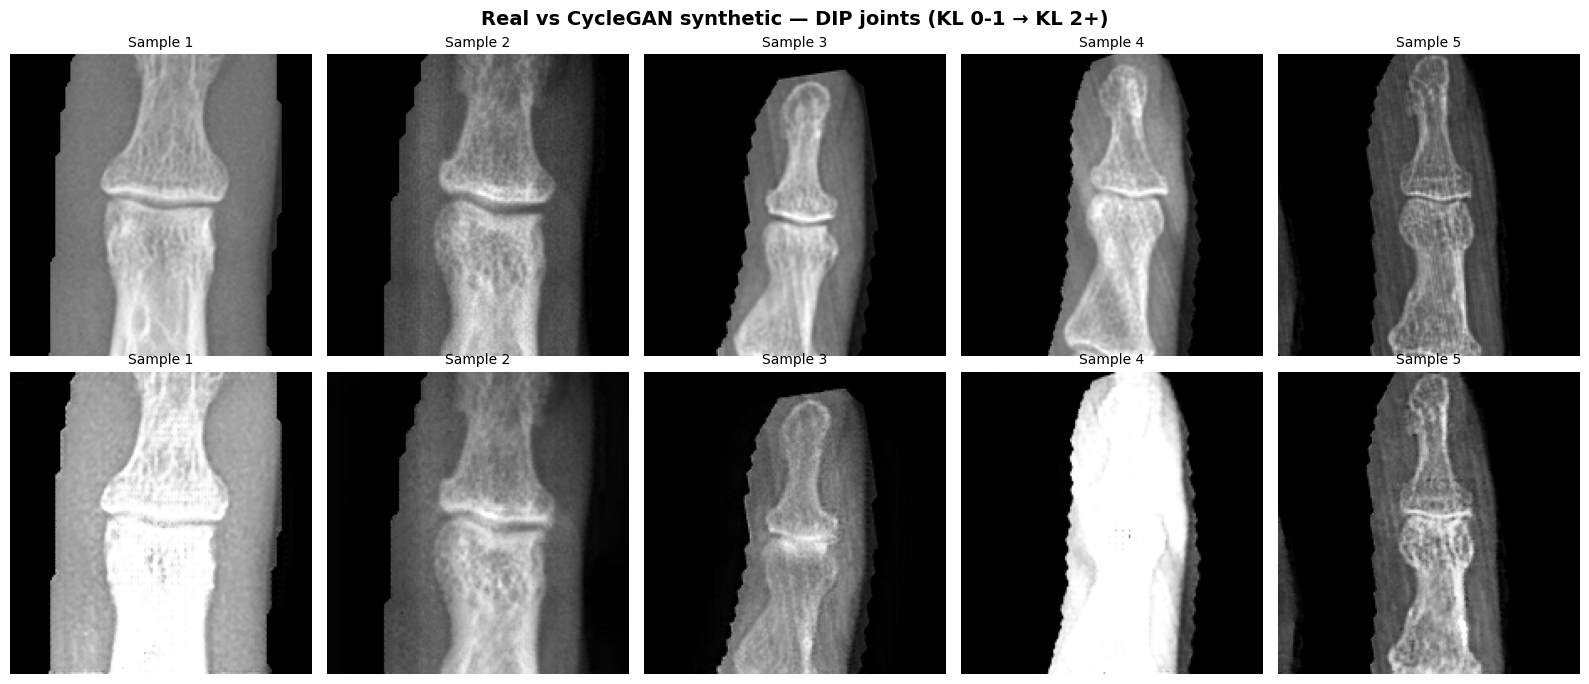

✅ Saved: real_vs_fake_organized.png


In [3]:
# ============================================================================
# FIXED: Organized Real vs Fake comparison for report
# Row 1: All REAL images | Row 2: All FAKE images (same order)
# ============================================================================

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Real vs CycleGAN synthetic — DIP joints (KL 0-1 → KL 2+)',
             fontsize=14, fontweight='bold')

axes[0][0].set_ylabel('Real\n(KL 0-1 input)', fontsize=12, fontweight='bold', color='green')
axes[1][0].set_ylabel('CycleGAN\n(Fake KL 2+)', fontsize=12, fontweight='bold', color='red')

healthy_paths = domain_a_df['image_path'].tolist()

for i in range(5):
    idx = i * 120
    if idx >= len(healthy_paths):
        idx = i * 10

    img = Image.open(healthy_paths[idx]).convert('L')
    img_t = transform_test(img).unsqueeze(0).to(device)
    with torch.no_grad():
        fake = G_AB(img_t)

    real_np = np.array(img.resize((IMG_SIZE, IMG_SIZE)))
    fake_np = (denormalize(fake.squeeze().cpu()).clamp(0, 1).numpy() * 255).astype(np.uint8)

    # Row 1: all real
    axes[0][i].imshow(real_np, cmap='gray')
    axes[0][i].set_title(f'Sample {i+1}', fontsize=10)
    axes[0][i].axis('off')

    # Row 2: all fake (same input order)
    axes[1][i].imshow(fake_np, cmap='gray')
    axes[1][i].set_title(f'Sample {i+1}', fontsize=10)
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'real_vs_fake_organized.png'), dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: real_vs_fake_organized.png")